In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import skew

# ------------------------------------------------------------
# 1. LOAD & BASIC CLEANING
# ------------------------------------------------------------
df = pd.read_csv('v3_master_combined.csv') 

df = df.drop("Brand Name", axis=1)
df = df.drop(columns=["Total_Sale_Normalized"])

df = df.dropna(subset=["Total Sale"])

# uncomment if loading fresh

df["Date"] = pd.to_datetime(df["Date"])
df = df.drop_duplicates()


if "total_sale_normalized" in df.columns:
    df = df.drop(columns=["total_sale_normalized"])

df = df.drop(columns=[c for c in ["postcode", "outercode"] if c in df.columns])


# Keep only the real, continuous data window (drops unrelated 2010-2013 branches)
df = df[df["Date"].dt.year >= 2020].copy()

df = df.dropna(subset=["Total Sale"])

# ------------------------------------------------------------
# 2. LAG / ROLLING FEATURES (per branch)
# ------------------------------------------------------------
df = df.sort_values(["Branch Name", "Date"]).reset_index(drop=True)

df["sales_lag_1"] = df.groupby("Branch Name")["Total Sale"].shift(1)
df["sales_lag_7"] = df.groupby("Branch Name")["Total Sale"].shift(7)
df["sales_roll_7_mean"] = (
    df.groupby("Branch Name")["Total Sale"]
    .shift(1)
    .rolling(7)
    .mean()
    .reset_index(0, drop=True)
)
df["sales_roll_30_mean"] = (
    df.groupby("Branch Name")["Total Sale"]
    .shift(1)
    .rolling(30)
    .mean()
    .reset_index(0, drop=True)
)
df["branch_dow_avg"] = df.groupby(["Branch Name", "Day_of_Week"])[
    "Total Sale"
].transform(lambda x: x.shift(1).expanding().mean())

lag_cols = [
    "sales_lag_1",
    "sales_lag_7",
    "sales_roll_7_mean",
    "sales_roll_30_mean",
    "branch_dow_avg",
]
df = df.dropna(subset=lag_cols)

# Re-sort by date only, now that lag features are computed
df = df.sort_values("Date").reset_index(drop=True)


# ------------------------------------------------------------
# 3. MULTICOLLINEARITY CHECK (drop features correlated > 0.95)
# ------------------------------------------------------------
numeric_cols = df.select_dtypes(include=np.number).columns.drop(
    "Total Sale", errors="ignore"
)
corr_matrix = df[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print("Dropping (multicollinearity):", to_drop)
df = df.drop(columns=to_drop)


# ------------------------------------------------------------
# 4. TEMPORAL TRAIN/TEST SPLIT
# ------------------------------------------------------------
split_date = df["Date"].quantile(0.8, interpolation="nearest")

train = df[df["Date"] < split_date].copy()
test = df[df["Date"] >= split_date].copy()

print(f"Train: {train['Date'].min()} to {train['Date'].max()} ({len(train)} rows)")
print(f"Test:  {test['Date'].min()} to {test['Date'].max()} ({len(test)} rows)")

X_train = train.drop(columns=["Total Sale", "Date"])
y_train = train["Total Sale"]
X_test = test.drop(columns=["Total Sale", "Date"])
y_test = test["Total Sale"]


# ------------------------------------------------------------
# 5. ENCODING
# ------------------------------------------------------------
encoder = TargetEncoder(cols=["Branch Name"])
X_train["Branch Name"] = encoder.fit_transform(X_train["Branch Name"], y_train)
X_test["Branch Name"] = encoder.transform(X_test["Branch Name"])

categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
print("One-hot encoding:", categorical_cols)
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print(
    "NaNs -> X_train:",
    X_train.isnull().sum().sum(),
    "| X_test:",
    X_test.isnull().sum().sum(),
)


# ------------------------------------------------------------
# 6. SCALING
# ------------------------------------------------------------
numeric_features = X_train.select_dtypes(include="number").columns.tolist()

constant_cols = [c for c in numeric_features if X_train[c].nunique() <= 1]
X_train = X_train.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)
numeric_features = [c for c in numeric_features if c not in constant_cols]

binary_cols = [c for c in numeric_features if X_train[c].dropna().isin([0, 1]).all()]
continuous_cols = [c for c in numeric_features if c not in binary_cols]

skew_vals = X_train[continuous_cols].apply(lambda x: skew(x.dropna()))
standard_cols = skew_vals[abs(skew_vals) < 0.5].index.tolist()
robust_cols = skew_vals[abs(skew_vals) >= 0.5].index.tolist()

standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

X_train[standard_cols] = standard_scaler.fit_transform(X_train[standard_cols])
X_test[standard_cols] = standard_scaler.transform(X_test[standard_cols])

X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
X_test[robust_cols] = robust_scaler.transform(X_test[robust_cols])


# ------------------------------------------------------------
# 7. BASELINE MODELS
# ------------------------------------------------------------
baselines = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

results = []
for name, model in baselines.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append(
        {
            "Model": name,
            "MAE": mean_absolute_error(y_test, preds),
            "MSE": mean_squared_error(y_test, preds),
            "R2": r2_score(y_test, preds),
        }
    )

results_df = pd.DataFrame(results)
print("\n=== Results ===")
print(results_df)

importances = pd.Series(
    baselines["GradientBoosting"].feature_importances_, index=X_train.columns
)
print("\n=== Top 15 Feature Importances ===")
print(importances.sort_values(ascending=False).head(15))


Dropping (multicollinearity): ['working', 'unemployed', 'non-white', 'Transport_Accessibility_Score', 'distance_to_nearest_station_mi', 'sales_roll_30_mean']
Train: 2020-01-31 00:00:00 to 2024-10-13 00:00:00 (44139 rows)
Test:  2024-10-14 00:00:00 to 2025-06-30 00:00:00 (11078 rows)
One-hot encoding: ['Day_of_Week', 'Nearest_Station_Type', 'Dataset', 'Inferred_Brand']
NaNs -> X_train: 0 | X_test: 0

=== Results ===
              Model         MAE           MSE        R2
0  LinearRegression  161.534962  68220.757701  0.754461
1      RandomForest  155.543933  61403.157223  0.778999
2  GradientBoosting  152.491989  59242.557946  0.786776

=== Top 15 Feature Importances ===
sales_roll_7_mean              0.684283
sales_lag_7                    0.156987
sales_lag_1                    0.089072
branch_dow_avg                 0.048604
is_weekend                     0.004837
Day_of_Week_Sunday             0.003279
is_ramadan                     0.001703
Branch Name                    0.001130
D

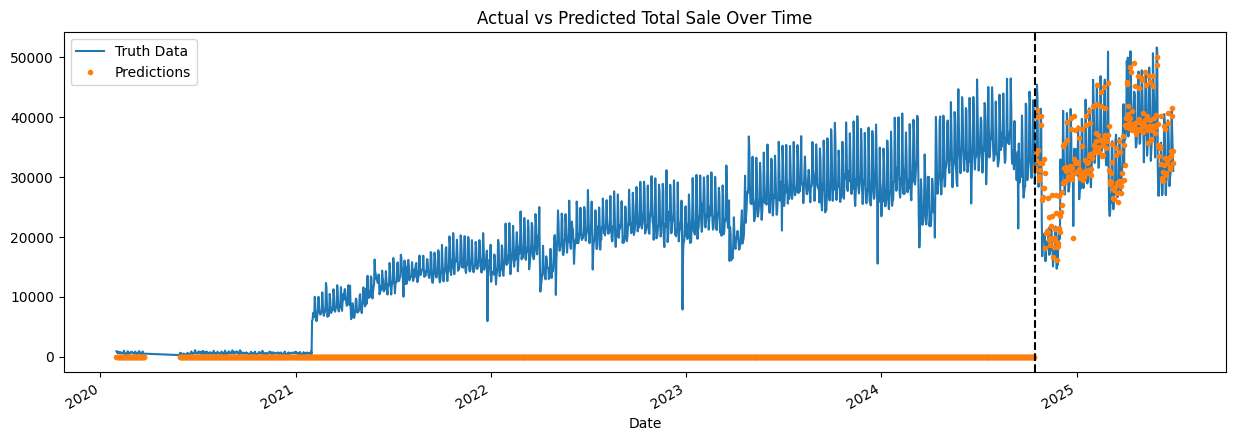

In [5]:
# Attach predictions to the test set
test = test.copy()
test["prediction"] = baselines["GradientBoosting"].predict(X_test)

# Merge predictions back into the full df, aligned by index
df_plot = df.merge(test[["prediction"]], how="left", left_index=True, right_index=True)

# Aggregate to daily totals (since you have multiple branches per day, like before)
daily_actual = df_plot.groupby("Date")["Total Sale"].sum()
daily_pred = df_plot.groupby("Date")["prediction"].sum()

fig, ax = plt.subplots(figsize=(15, 5))
daily_actual.plot(ax=ax, label="Truth Data")
daily_pred.plot(ax=ax, style=".", label="Predictions")
ax.axvline(split_date, color="black", ls="--")
ax.legend(["Truth Data", "Predictions"])
ax.set_title("Actual vs Predicted Total Sale Over Time")
plt.show()


In [6]:
target_mean = np.mean(y_train)
print(f"Target Average: {target_mean}")


Target Average: 703.42949636376


# **Till Now Code is Perfect**

In [ ]:
# from turtle import mode

# import optuna 

# from sklearn.ensemble import RandomForestRegressor

# from sklearn.model_selection import TimeSeriesSplit,cross_val_score
# from xgboost import cv


# tscv = TimeSeriesSplit(n_splits=3)



# def objective(trial):
#   n_estimators = trial.suggest_int('n_estimators',100,500)


#   max_depth = trial.suggest_int('max_depth',4,20)

#   min_samples_leaf = trial.suggest_int('min_samples_leaf',1,10)


#   model = RandomForestRegressor(
#     n_estimators=n_estimators,
#     max_depth=max_depth,
#     min_samples_leaf=min_samples_leaf,
#     random_state=42,
#     n_jobs=-1
#   )
#   score = cross_val_score(model,X_train,y_train,cv=tscv,scoring='r2').mean()

#   return score


In [ ]:
# study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler())

# study.optimize(objective,n_trials=50)



[I 2026-08-11 00:16:36,918] A new study created in memory with name: no-name-cf3438f0-1b29-42a7-b013-d01e8b65952a
[I 2026-08-11 00:17:27,816] Trial 0 finished with value: 0.8279773234475707 and parameters: {'n_estimators': 490, 'max_depth': 19, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.8279773234475707.
[I 2026-08-11 00:18:14,888] Trial 1 finished with value: 0.828313370092325 and parameters: {'n_estimators': 469, 'max_depth': 13, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.828313370092325.
[I 2026-08-11 00:18:56,003] Trial 2 finished with value: 0.826112520351321 and parameters: {'n_estimators': 358, 'max_depth': 13, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.828313370092325.
[I 2026-08-11 00:19:25,419] Trial 3 finished with value: 0.8267020906682121 and parameters: {'n_estimators': 274, 'max_depth': 12, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.828313370092325.
[I 2026-08-11 00:19:46,478] Trial 4 finished with value: 0.8266739914784295 an

KeyboardInterrupt: 

In [11]:
print("Best params:", study.best_params)
print("Best R²:", study.best_value)


Best params: {'n_estimators': 466, 'max_depth': 10, 'min_samples_leaf': 7}
Best R²: 0.8286510312318213


In [3]:
from turtle import mode

import optuna

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import TimeSeriesSplit,cross_val_score
from xgboost import cv


tscv = TimeSeriesSplit(n_splits=3)


def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 300, 800)
    max_depth = trial.suggest_int(
        "max_depth", 4, 20
    )  # keep as-is, it wasn't near an edge
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1,
    )

    score = cross_val_score(model, X_train, y_train, cv=tscv, scoring="r2").mean()
    return score


study2 = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study2.optimize(objective, n_trials=30)

print("Best params:", study2.best_params)
print("Best R²:", study2.best_value)


[I 2026-08-11 13:24:09,752] A new study created in memory with name: no-name-77cf6115-b9b2-4bc7-9357-c991df522623
[I 2026-08-11 13:24:44,003] Trial 0 finished with value: 0.827066516581767 and parameters: {'n_estimators': 332, 'max_depth': 11, 'min_samples_leaf': 18}. Best is trial 0 with value: 0.827066516581767.
[I 2026-08-11 13:26:10,540] Trial 1 finished with value: 0.8283937429556602 and parameters: {'n_estimators': 774, 'max_depth': 11, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.8283937429556602.
[I 2026-08-11 13:26:40,357] Trial 2 finished with value: 0.8240454303582401 and parameters: {'n_estimators': 320, 'max_depth': 8, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.8283937429556602.
[I 2026-08-11 13:27:12,650] Trial 3 finished with value: 0.8148712538379851 and parameters: {'n_estimators': 534, 'max_depth': 5, 'min_samples_leaf': 12}. Best is trial 1 with value: 0.8283937429556602.
[I 2026-08-11 13:27:54,075] Trial 4 finished with value: 0.827048547812068 a

KeyboardInterrupt: 

# **Till Now Everything is okay and oputna is porividing the results for the Random Forest Perfectly**

In [5]:
best_model = RandomForestRegressor(
  **study2.best_trial.params,random_state=42,n_jobs=-1
)


best_model.fit(X_train,y_train)

y_pred = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test,y_pred)

test_mse = mean_squared_error(y_test, y_pred)

test_r2 = r2_score(y_test, y_pred)



print(f'Test MAE : {test_mae: .2f}')

print(f'Test MSE {test_mse: .2f}')

print(f'Test R2 Score :{test_r2:.2f}')


Test MAE :  151.99
Test MSE  60286.81
Test R2 Score :0.78


In [6]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)
print("GB Test R²:", r2_score(y_test, gb_preds))


GB Test R²: 0.7867756178115137


In [ ]:
# For visualizations
from optuna.visualization import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_slice,
    plot_contour,
    plot_param_importances,
)


C:\Users\farma\AppData\Local\Temp\ipykernel_25260\297899428.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna_mpl.plot_optimization_history(study2)


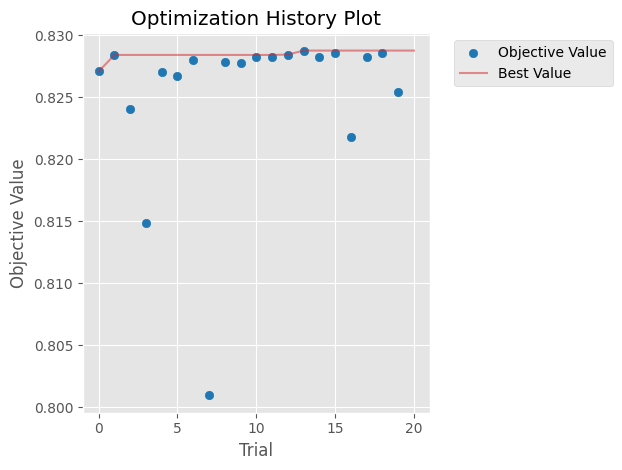

In [12]:
# 1. Optimization History
import optuna.visualization.matplotlib as optuna_mpl

optuna_mpl.plot_optimization_history(study2)
plt.show()


C:\Users\farma\AppData\Local\Temp\ipykernel_25260\4285833729.py:2: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  optuna_mpl.plot_parallel_coordinate(study2)


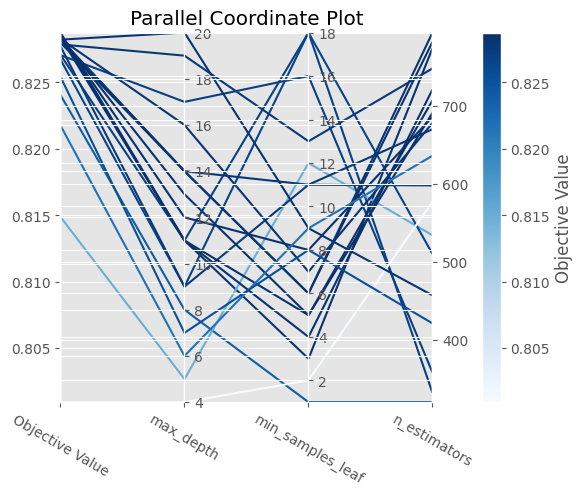

In [13]:
# 2. Parallel Coordinates Plot
optuna_mpl.plot_parallel_coordinate(study2)
plt.show()


C:\Users\farma\AppData\Local\Temp\ipykernel_25260\293001363.py:2: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  optuna_mpl.plot_slice(study2)


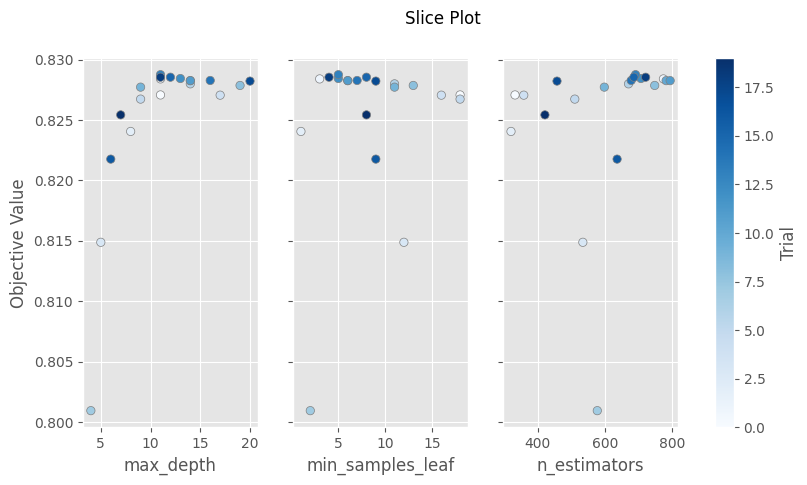

In [15]:
# 3. Slice Plot
optuna_mpl.plot_slice(study2)
plt.show()


C:\Users\farma\AppData\Local\Temp\ipykernel_25260\3864161348.py:2: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  optuna_mpl.plot_contour(study2)


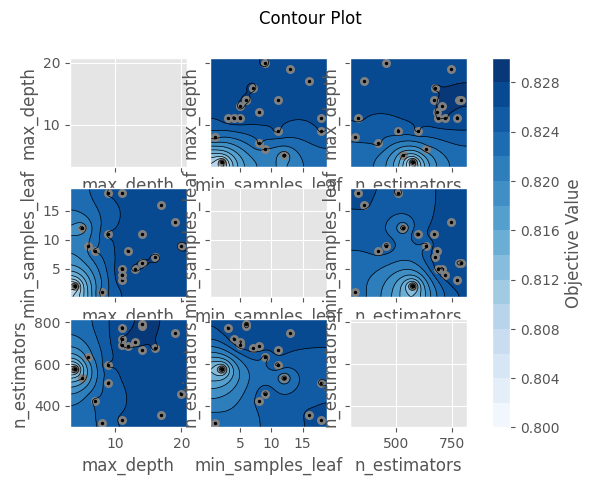

In [16]:
# 4. Contour Plot
optuna_mpl.plot_contour(study2)
plt.show()


C:\Users\farma\AppData\Local\Temp\ipykernel_25260\833608515.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna_mpl.plot_param_importances(study2)


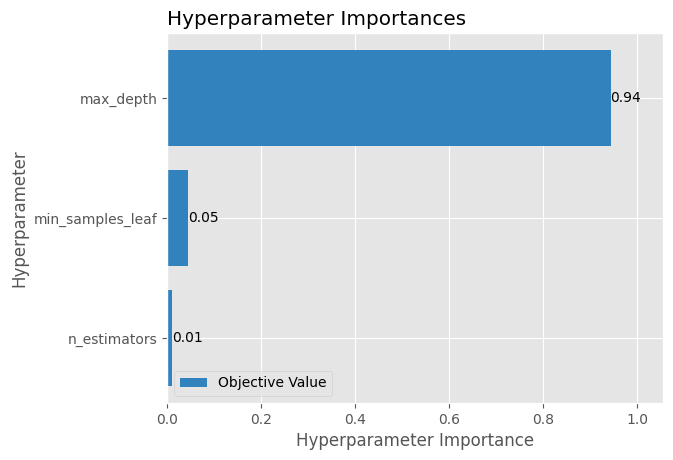

In [17]:
# 5. Hyperparameter Importance
optuna_mpl.plot_param_importances(study2)
plt.show()


# **Till Now Everything is okay and oputna is porividing the results for the Random Forest Perfectly**

In [18]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
  n_estimators = 400,
  max_depth = 6,
  learning_rate = 0.05,
  subsample =0.8,
  random_state = 42
)


xgb_model.fit(X_train,y_train)

xgb_preds = xgb_model.predict(X_test)

print("XGBoost MAE:", mean_absolute_error(y_test, xgb_preds))
print("XGBoost MSE:", mean_squared_error(y_test, xgb_preds))
print("XGBoost R²:", r2_score(y_test, xgb_preds))


XGBoost MAE: 157.06493423323485
XGBoost MSE: 62281.210210259014
XGBoost R²: 0.775838974051795


In [20]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=20,
    min_child_samples=10,
    subsample=0.8,
    random_state=42,
)

lgbm_model.fit(X_train, y_train)
lgbm_preds = lgbm_model.predict(X_test)

print("LightGBM MAE:", mean_absolute_error(y_test, lgbm_preds))
print("LightGBM MSE:", mean_squared_error(y_test, lgbm_preds))
print("LightGBM R²:", r2_score(y_test, lgbm_preds))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.108512 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2132
[LightGBM] [Info] Number of data points in the train set: 44139, number of used features: 48
[LightGBM] [Info] Start training from score 703.429496
LightGBM MAE: 151.01790216113687
LightGBM MSE: 59391.57595573924
LightGBM R²: 0.7862392757948324


In [21]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3.0,
    random_state=42,
    verbose=0,
)

cat_model.fit(X_train, y_train)
cat_preds = cat_model.predict(X_test)

print("CatBoost MAE:", mean_absolute_error(y_test, cat_preds))
print("CatBoost MSE:", mean_squared_error(y_test, cat_preds))
print("CatBoost R²:", r2_score(y_test, cat_preds))


CatBoost MAE: 150.28779384983054
CatBoost MSE: 58612.4038090377
CatBoost R²: 0.7890436533463481


In [22]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=3)


def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 300, 800)
    max_depth = trial.suggest_int(
        "max_depth", 4, 10
    )  # CatBoost depth caps around 16 max; kept tighter for boosting
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    min_data_in_leaf = trial.suggest_int("min_data_in_leaf", 1, 20)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1.0, 10.0)

    model = CatBoostRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        min_data_in_leaf=min_data_in_leaf,
        l2_leaf_reg=l2_leaf_reg,
        random_state=42,
        thread_count=-1,
        verbose=0,
    )

    score = cross_val_score(model, X_train, y_train, cv=tscv, scoring="r2").mean()
    return score


study_cat = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler()
)
study_cat.optimize(objective, n_trials=30)

print("Best params:", study_cat.best_params)
print("Best CV R²:", study_cat.best_value)

# Train final model with best params
best_cat = CatBoostRegressor(
    **study_cat.best_params, random_state=42, thread_count=-1, verbose=0
)
best_cat.fit(X_train, y_train)

cat_test_preds = best_cat.predict(X_test)
from sklearn.metrics import r2_score

print("Test R² with tuned params:", r2_score(y_test, cat_test_preds))


[I 2026-08-11 14:48:11,104] A new study created in memory with name: no-name-7e5708e1-76f8-40e8-b9c2-cb92a1cd864e
[I 2026-08-11 14:48:21,987] Trial 0 finished with value: 0.8300439619767909 and parameters: {'n_estimators': 304, 'max_depth': 7, 'learning_rate': 0.03207944998622764, 'min_data_in_leaf': 3, 'l2_leaf_reg': 2.4846609259228885}. Best is trial 0 with value: 0.8300439619767909.
[I 2026-08-11 14:48:46,078] Trial 1 finished with value: 0.824141860666205 and parameters: {'n_estimators': 386, 'max_depth': 9, 'learning_rate': 0.03790414389173282, 'min_data_in_leaf': 2, 'l2_leaf_reg': 1.143883395219262}. Best is trial 0 with value: 0.8300439619767909.
[I 2026-08-11 14:50:38,394] Trial 2 finished with value: 0.8085625607018841 and parameters: {'n_estimators': 592, 'max_depth': 10, 'learning_rate': 0.15220170280894194, 'min_data_in_leaf': 16, 'l2_leaf_reg': 5.466344930419452}. Best is trial 0 with value: 0.8300439619767909.
[I 2026-08-11 14:51:02,348] Trial 3 finished with value: 0.825

Best params: {'n_estimators': 616, 'max_depth': 4, 'learning_rate': 0.042100402600074895, 'min_data_in_leaf': 10, 'l2_leaf_reg': 4.466488597976442}
Best CV R²: 0.8402162177500871
Test R² with tuned params: 0.7905845227331467


In [24]:
best_cat = CatBoostRegressor(
    **study_cat.best_params, random_state=42, thread_count=-1, verbose=0
)
best_cat.fit(X_train, y_train)

cat_test_preds = best_cat.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Tuned CatBoost Test MAE:", mean_absolute_error(y_test, cat_test_preds))
print("Tuned CatBoost Test MSE:", mean_squared_error(y_test, cat_test_preds))
print(
    "Tuned CatBoost Test RMSE:",
)
print("Tuned CatBoost Test R²:", r2_score(y_test, cat_test_preds))


Tuned CatBoost Test MAE: 149.78589524950812
Tuned CatBoost Test MSE: 58184.28652245849
Tuned CatBoost Test RMSE:
Tuned CatBoost Test R²: 0.7905845227331467
